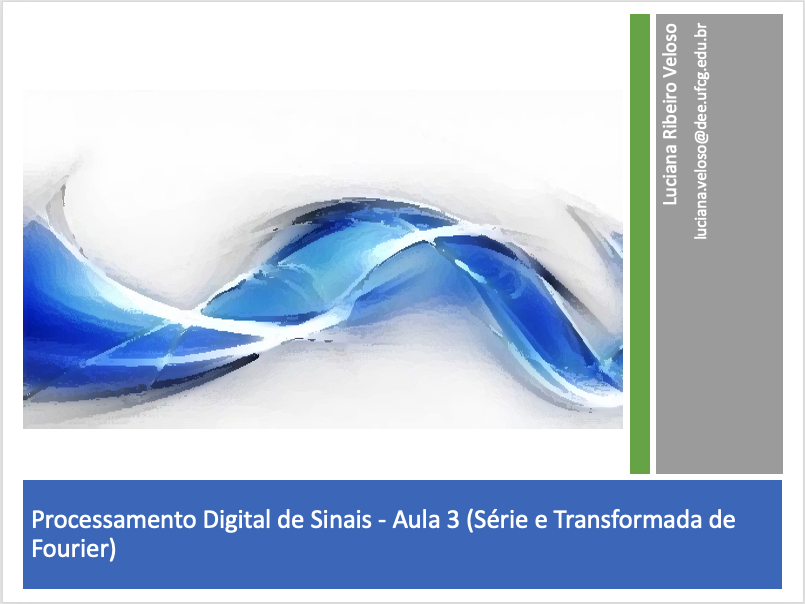

### Importação dos Pacotes

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.gridspec as gridspec
from IPython.display import Audio, display, clear_output
import ipywidgets as widgets
from scipy import signal  

# O Prisma de Fourier (Série e Transformada)

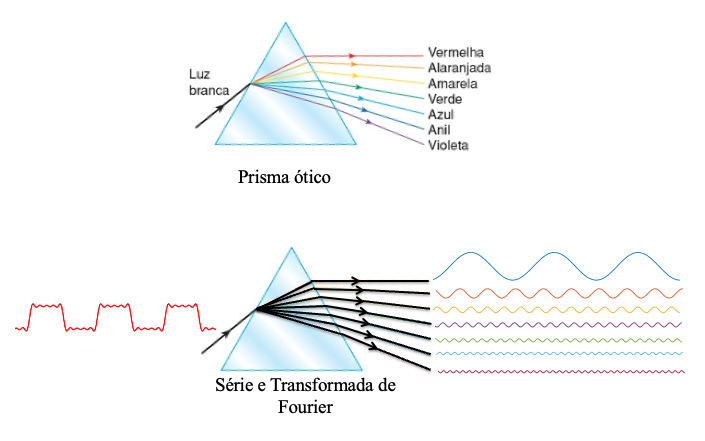

* Analogia do Prisma: Assim como o vidro decompõe a luz branca em cores, Fourier decompõe sinais complexos em senoides puras.

* Série de Fourier: Para sinais que se repetem (periódicos). Resulta em um espectro discreto (harmônicos).

* Transformada de Fourier: Para sinais quaisquer (aperiódicos/ruídos). Resulta em um espectro contínuo.

* Utilidade: Filtragem de ruído, compressão MP3 e equalização de áudio.

## Série trigonométrica de Fourier

 $$x(t) = a_0 + \sum_{n=1}^{\infty} [a_n \cos(n\omega_0t) + b_n \text{sen}(n\omega_0t)] \quad \omega_0 = \frac{2\pi}{T_0}$$

 $$a_0 = \frac{1}{T_0} \int_{<T_0>} x(t)dt \quad \text{Média do sinal}$$

 $$a_n = \frac{2}{T_0} \int_{<T_0>} x(t) \cos(n\omega_0t) dt \quad b_n = \frac{2}{T_0} \int_{<T_0>} x(t) \text{sen}(n\omega_0t) dt$$

# Tabela de Coeficientes de Fourier para Formas de Onda Comuns

A Série de Fourier decompõe sinais periódicos em componentes de frequência. A tabela abaixo resume os coeficientes $a_n$ (componentes de cosseno) e $b_n$ (componentes de seno) para as ondas fundamentais:

### Tabela 1: Coeficientes de Fourier

| Onda quadrada | Onda triangular | Onda dente de serra |
| :--- | :--- | :--- |
| $a_n = 0$ | $a_n = \begin{cases} -\frac{8}{\pi^2 n^2}, & \text{para } n = 1, 3, 5, \dots \\ 0, & \text{caso contrário.} \end{cases}$ | $a_n = 0$ |
| $b_n = \begin{cases} \frac{4}{\pi n}, & \text{para } n = 1, 3, 5, \dots \\ 0, & \text{caso contrário.} \end{cases}$ | $b_n = 0$ | $b_n = \begin{cases} -\frac{2}{\pi n}, & \text{para } n \neq 0 \\ 0, & \text{para } n = 0 \end{cases}$ |


# Simulador de Série de Fourier Interativo

In [3]:

# 1. Configurações de tempo
t = np.linspace(0, 2, 1000) # 2 segundos de visualização

def gerar_simulador(tipo_sinal, n_harmonicos, freq_fund, amp_base):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    soma_final = np.zeros_like(t)
    cores = plt.cm.viridis(np.linspace(0, 1, n_harmonicos))

    # 2. Loop para calcular e plotar cada harmônico
    for i in range(1, n_harmonicos + 1):
        # Definição dos coeficientes de Fourier
        if tipo_sinal == 'Onda Quadrada':
            n = 2 * i - 1  # Apenas ímpares (1, 3, 5...)
            amp = (4 / (np.pi * n)) * amp_base
            onda = amp * np.sin(2 * np.pi * n * freq_fund * t)
            label = f'Harmônico {n}'

        elif tipo_sinal == 'Dente de Serra':
            n = i          # Todos os harmônicos (1, 2, 3...)
            amp = (2 / (np.pi * n)) * amp_base
            onda = amp * np.sin(2 * np.pi * n * freq_fund * t)
            label = f'Harmônico {n}'

        elif tipo_sinal == 'Onda Triangular':
            n = 2 * i - 1  # Apenas ímpares
            amp = (-8 / ((np.pi * n)**2)) * amp_base
            # Alterna sinal para fase correta
            onda = amp * np.cos(2 * np.pi * n * freq_fund * t)
            label = f'Harmônico {n}'

        soma_final += onda

        # Plot das ondas individuais (Esquerda)
        ax1.plot(t, onda, label=label if i <= 5 else None, color=cores[i-1], alpha=0.6)

    # 3. Estilização do Gráfico de Harmônicos
    ax1.set_title(f"Harmônicos Individuais (As ondas individuais)\n{tipo_sinal}", fontsize=13)
    ax1.set_ylim(-1.3, 1.3)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlabel("Tempo (segundos)")
    ax1.set_ylabel("Magnitude")

    # 4. Plot da Soma Acumulada (Direita)
    ax2.plot(t, soma_final, color='red', lw=2.5)
    ax2.set_title(f"Soma Acumulada (Sinal Complexo Resultante)\nN={n_harmonicos} componentes", fontsize=13)
    ax2.set_ylim(-1.3, 1.3)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlabel("Tempo (segundos)")

    plt.tight_layout()
    plt.show()

# 5. Widgets da Interface
tipo_select = widgets.Dropdown(
    options=['Onda Quadrada', 'Dente de Serra', 'Onda Triangular'],
    value='Onda Quadrada',
    description='Sinal Base:'
)

n_slider = widgets.IntSlider(value=7, min=1, max=50, description='Harmônicos (N):', layout={'width': '400px'})
f_slider = widgets.FloatSlider(value=1.0, min=0.5, max=5.0, description='Freq Fund (Hz):')
a_slider = widgets.FloatSlider(value=1.0, min=0.1, max=1.2, description='Amplitude:')

# 6. Saída Interativa
out = widgets.interactive_output(gerar_simulador, {
    'tipo_sinal': tipo_select,
    'n_harmonicos': n_slider,
    'freq_fund': f_slider,
    'amp_base': a_slider
})

ui = widgets.VBox([
    widgets.HTML("<h2>Simulador de Série de Fourier Interativo</h2>"),
    widgets.HBox([tipo_select, f_slider]),
    widgets.HBox([n_slider, a_slider]),
    out
])

display(ui)

# Sintetizador Interativo

In [10]:

# 1. Configurações Globais de Áudio e Tempo
sample_rate = 44100
duration = 1.0
t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
pts_plot = 600  # Quantidade de pontos para visualização temporal estável

# 2. Definição dos Widgets de Interface
freq_slider = widgets.FloatLogSlider(
    value=440.0, base=10, min=1.3, max=3.7, step=0.01,
    description='Freq (Hz):', layout=widgets.Layout(width='90%')
)

wave_select = widgets.ToggleButtons(
    options=['Seno', 'Onda Quadrada', 'Dente de Serra', 'Noise'],
    description='Onda:',
    button_style='info',
)

# Área de saída para os gráficos
output_area = widgets.Output()

# 3. Função Principal de Processamento e Visualização
def update_app(frequency, wave_type):
    # Geração do Sinal
    if wave_type == 'Seno':
        y = np.sin(2 * np.pi * frequency * t)
    elif wave_type == 'Onda Quadrada':
        y = signal.square(2 * np.pi * frequency * t)
    elif wave_type == 'Dente de Serra':
        y = signal.sawtooth(2 * np.pi * frequency * t)
    else:  # Noise (Ruído Branco)
        y = np.random.uniform(-1, 1, len(t))

    # Cálculo da FFT (Magnitude Real)
    n = len(y)
    yf = np.fft.rfft(y)
    xf = np.fft.rfftfreq(n, 1/sample_rate)
    mags = np.abs(yf) * 2 / n

    with output_area:
        clear_output(wait=True)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

        # --- Gráfico 1: Domínio do Tempo ---
        ax1.plot(t[:pts_plot], y[:pts_plot], color='#0097a7', lw=2)
        ax1.set_title(f"Forma de Onda: {wave_type}")
        ax1.set_xlabel("Tempo (s)")
        ax1.set_ylabel("Amplitude")
        ax1.grid(True, alpha=0.2)

        # --- Gráfico 2: Domínio da Frequência (Espectro) ---
        if wave_type == 'Noise':
            # Escala dinâmica para o ruído (energia distribuída)
            ax2.plot(xf, mags, color='gray', alpha=0.5, lw=0.5)
            ax2.set_xlim(0, 20000)
            ax2.set_ylim(0, max(mags) * 1.5 if max(mags) > 0 else 1)
        else:
            # Escala fixa para ondas periódicas (energia concentrada)
            limit_freq = max(frequency * 10, 2000)
            mask = (xf <= limit_freq)
            
            # Visualização por impulsos (stem-like)
            ax2.plot(xf[mask], mags[mask], color='red', lw=1.5)
            ax2.fill_between(xf[mask], mags[mask], color='red', alpha=0.3)
            
            ax2.set_xlim(0, limit_freq)
            ax2.set_ylim(0, 1.1)

        # Uso de raw string r"" para evitar SyntaxWarning com \omega ou \pi
        ax2.set_title(r"Espectro de Magnitude $|X(f)|$")
        ax2.set_xlabel("Frequência (Hz)")
        ax2.grid(True, alpha=0.2)

        plt.tight_layout()
        plt.show()

        # Player de áudio
        display(Audio(y, rate=sample_rate, autoplay=False))

# 4. Acoplamento e Exibição Final
out = widgets.interactive_output(update_app, {
    'frequency': freq_slider,
    'wave_type': wave_select
})

layout_final = widgets.VBox([
    widgets.HTML("<h2>Sintetizador Interativo: Tempo vs. Frequência</h2>"),
    freq_slider,
    wave_select,
    output_area
])

display(layout_final)